# 1. Importing Libraries

In [80]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# 2. Generate The Data

In [23]:
X,y = make_classification(n_samples=200 ,
                          n_features=2  ,
                          random_state=42,
                          n_clusters_per_class=2,
                          n_informative=2,
                          n_redundant=0)

In [76]:
X = pd.DataFrame(X, columns=["X0" , "X1"])
y = pd.DataFrame(y , columns=["y"])

In [28]:
print(X)
print(y)

           X0        X1
0    1.689767 -1.408241
1    1.530287 -1.459848
2   -1.175042 -1.447633
3   -2.585395  0.963532
4    1.372246  0.440695
..        ...       ...
195 -0.435396  0.715716
196  1.040417  1.108613
197  1.883798  0.782433
198  1.829367  1.542978
199 -0.855041 -0.109436

[200 rows x 2 columns]
     y
0    1
1    1
2    0
3    0
4    1
..  ..
195  0
196  1
197  0
198  1
199  0

[200 rows x 1 columns]


In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the model

In [68]:
model = DecisionTreeClassifier()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

# 4. Evaluate the model

In [69]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[15  4]
 [ 5 16]]
              precision    recall  f1-score   support

           0       0.75      0.79      0.77        19
           1       0.80      0.76      0.78        21

    accuracy                           0.78        40
   macro avg       0.78      0.78      0.77        40
weighted avg       0.78      0.78      0.78        40



# 5. Plot

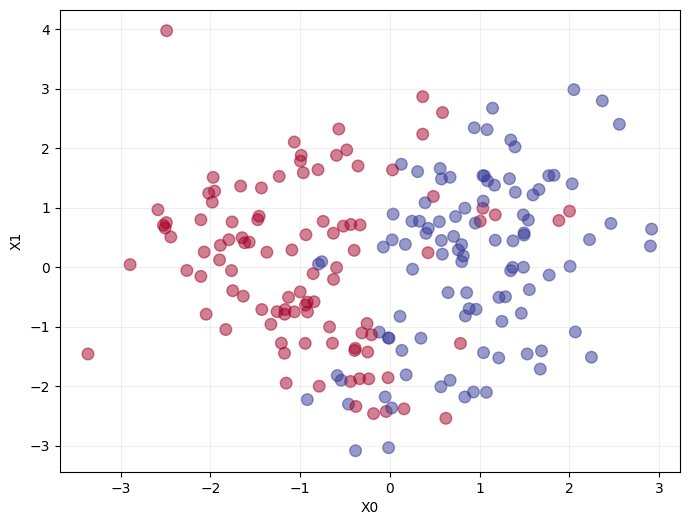

In [77]:
plt.style.use('default')
plt.figure(figsize=(8,6))
plt.scatter(X["X0"] , X["X1"], s=70 , alpha = 0.5, c = y["y"] ,cmap='RdYlBu')
plt.xlabel("X0")
plt.ylabel("X1")
plt.grid(True,alpha=0.2)
plt.show()

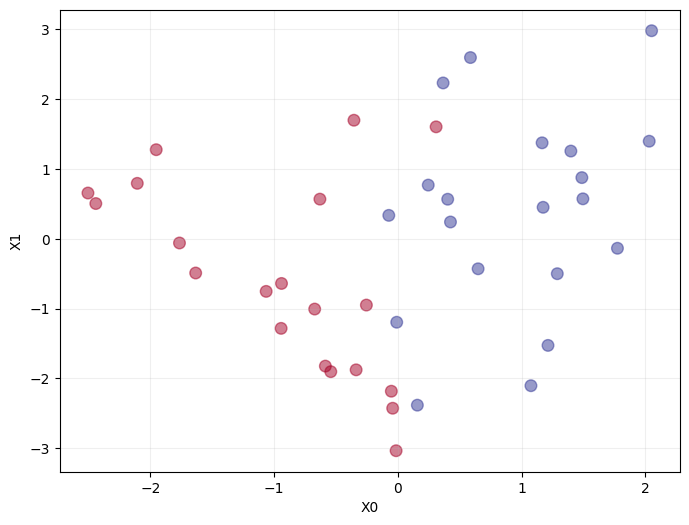

In [79]:
plt.style.use('default')
plt.figure(figsize=(8,6))
plt.scatter(X_test["X0"] , X_test["X1"], s=70 , alpha = 0.5, c = y_pred, cmap='RdYlBu')
plt.xlabel("X0")
plt.ylabel("X1")
plt.xlabel("X0")
plt.ylabel("X1")
plt.grid(True,alpha=0.2)
plt.show()

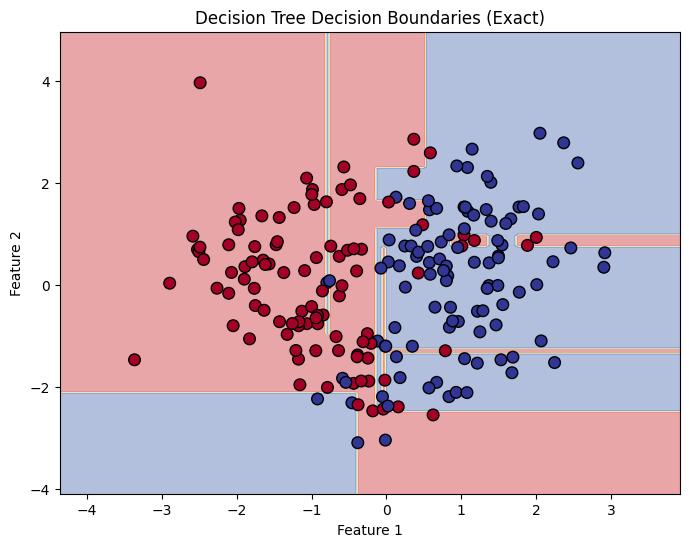

In [87]:
# Create grid
x_min, x_max = X["X0"].min() - 1, X["X0"].max() + 1
y_min, y_max = X["X1"].min() - 1, X["X1"].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# Convert to DataFrame (important!)
grid = pd.DataFrame(
    np.c_[xx.ravel(), yy.ravel()],
    columns=["X0", "X1"]
)

Z = model.predict(grid)
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, cmap="RdYlBu", alpha=0.4)
plt.scatter(
    X["X0"],
    X["X1"],
    c=y["y"],
    edgecolor="k",
    cmap="RdYlBu",
    s=70
)

plt.title("Decision Tree Decision Boundaries (Exact)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()
